In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Titanic-Dataset-Cleaned.csv")

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.5+ KB


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [14]:
ages = df['Age'].to_numpy()

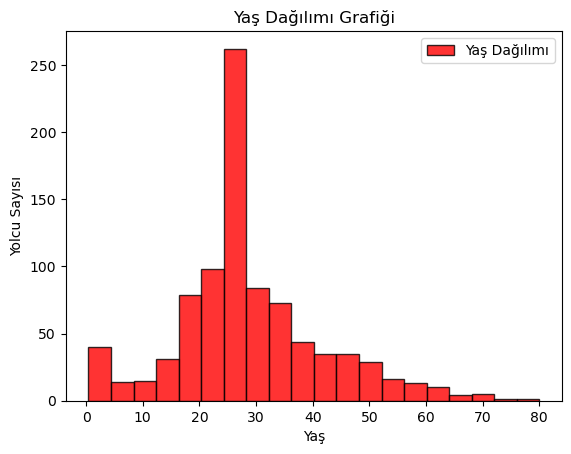

In [15]:
# Age geniş bir veri olduğu için 20 lik sütunlara ayırarak histogram grafiği oluşturdum
plt.hist(
    ages,
    bins=20,
    color='red',
    edgecolor='black',
    alpha=0.8,
    density=False,
    label='Yaş Dağılımı'
)
plt.title('Yaş Dağılımı Grafiği')
plt.xlabel('Yaş')
plt.ylabel('Yolcu Sayısı')
plt.legend()
plt.show()

In [19]:
fare = [df[df['Pclass'] == i]['Fare'].to_numpy() for i in [1, 2, 3]]

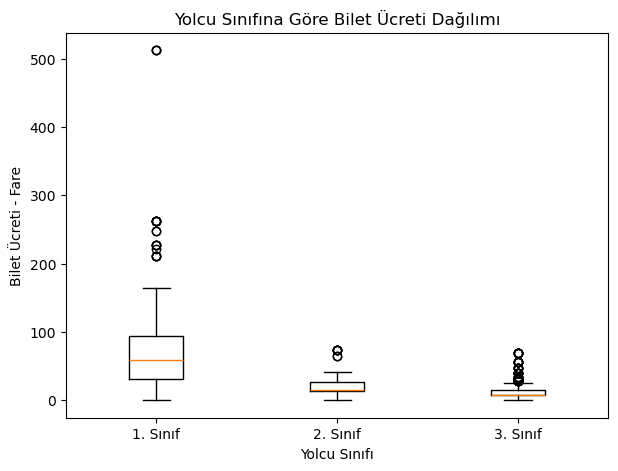

In [23]:
# Ücret dağılımları sınıflara göre daha rahat görülsün diye box plot seçtim
plt.figure(figsize=(7, 5))
plt.boxplot(fare, tick_labels=['1. Sınıf', '2. Sınıf', '3. Sınıf'])
plt.title('Yolcu Sınıfına Göre Bilet Ücreti Dağılımı')
plt.xlabel('Yolcu Sınıfı')
plt.ylabel('Bilet Ücreti - Fare')
plt.show()

In [26]:
fare_bins = [0, 50, 100, 150, 200, 250, 300, 550]
fare_labels = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300+']

In [29]:
df['FareGroup'] = pd.cut(df['Fare'], bins=fare_bins, labels=fare_labels)
survival_by_fare = df.groupby('FareGroup', observed=False)['Survived'].mean() * 100

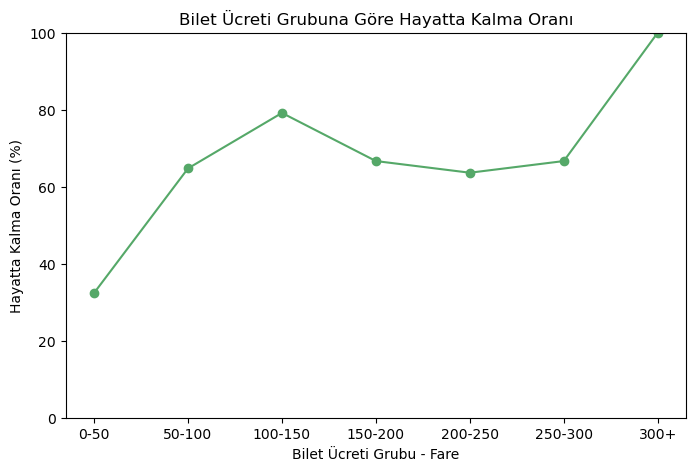

In [32]:
# Son olarak bilet ücreti ile hayatta kalma oranı için line chart grafiğini uygun gördüm
plt.figure(figsize=(8, 5))
plt.plot(survival_by_fare.index, survival_by_fare.values, marker='o', color='#55A868')
plt.title('Bilet Ücreti Grubuna Göre Hayatta Kalma Oranı')
plt.xlabel('Bilet Ücreti Grubu - Fare')
plt.ylabel('Hayatta Kalma Oranı (%)')
plt.ylim(0, 100)
plt.show()